In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

In [5]:
print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.28.4


In [7]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

We are interested in predicting outcomes 𝑌 as normally-distributed observations with an expected value 𝜇 that is a linear function of two predictor variables, $𝑋_1$ and $𝑋_2$:

𝑌∼N⁡(𝜇,$𝜎^2$)

𝜇=𝛼+$𝛽_1$⁢$X_1$+$𝛽_2$$𝑋_2$


where
𝛼 is the intercept, and $𝛽_𝑖$ is the coefficient for covariate $𝑋_𝑖$, while 𝜎 represents the observation error.
Since we are constructing a Bayesian model, we must assign a prior distribution to the unknown variables in the model. We choose zero-mean normal priors with variance of 100 for both regression coefficients, which corresponds to weak information regarding the true parameter values. We choose a half-normal distribution (normal distribution bounded at zero) as the prior for 𝜎:

𝛼∼N⁡(0,100)

$𝛽_𝑖$∼N⁡(0,100)

𝜎∼|N⁡(0,1)|

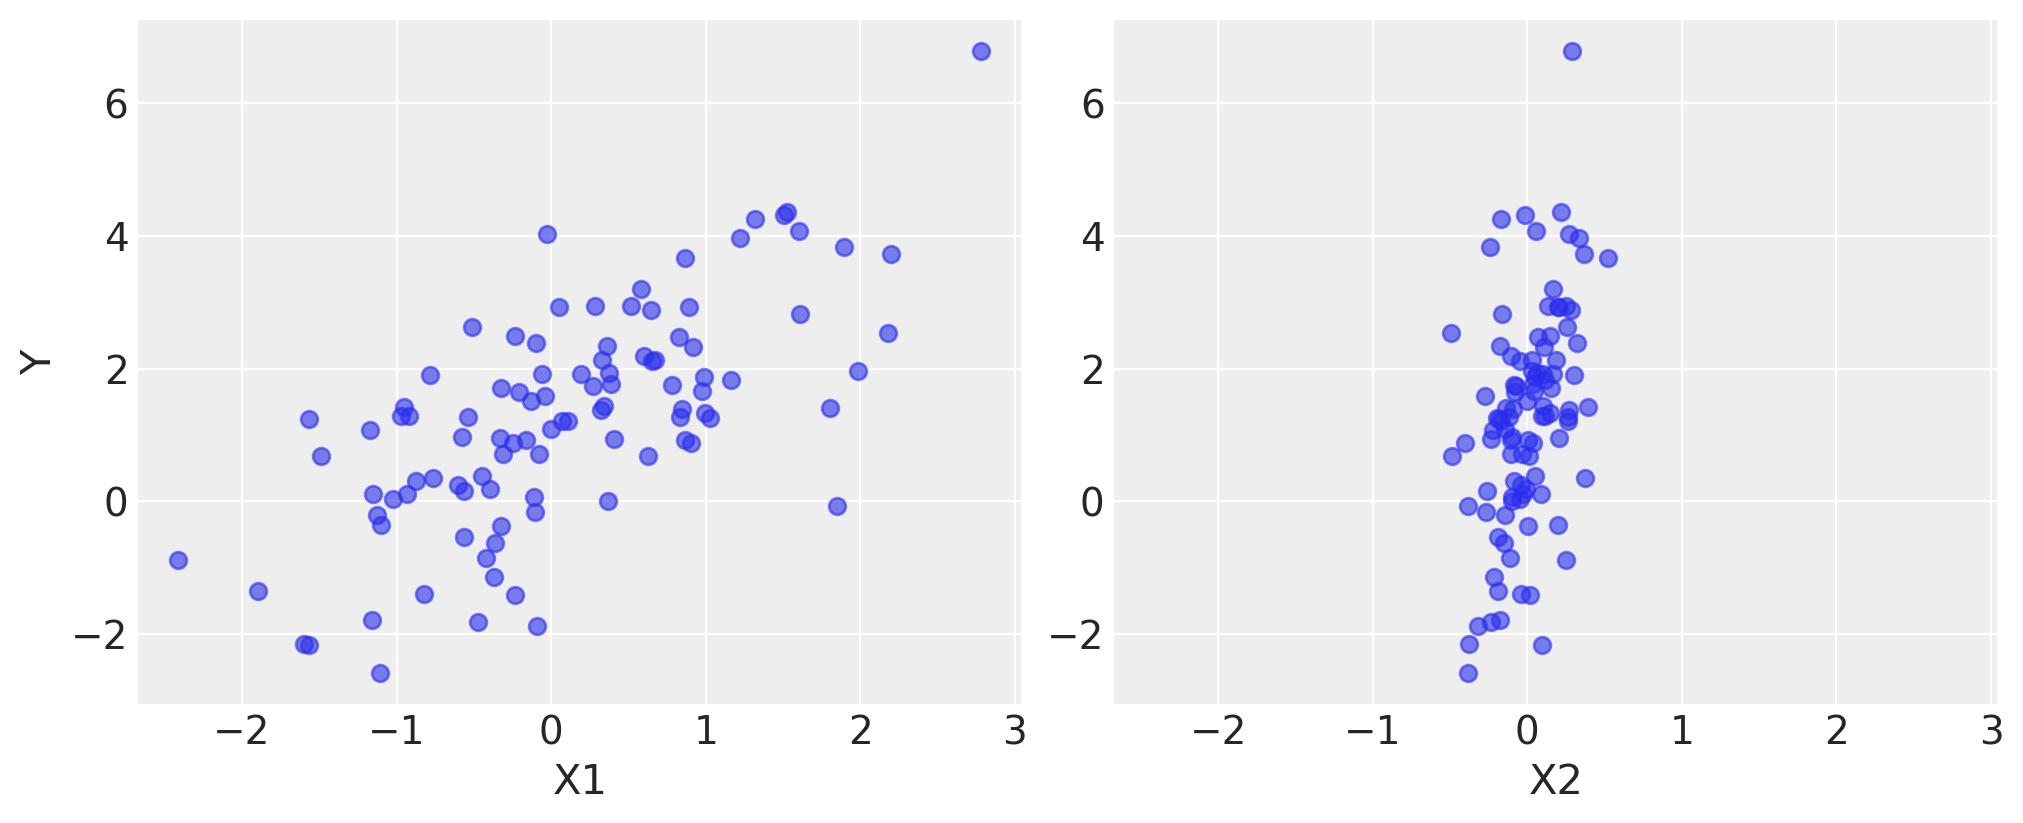

In [8]:
# True parameter values
alpha, sigma = 1, 1
beta = [1, 2.5]

# Size of dataset
size = 100

# Predictor variable
X1 = np.random.randn(size)
X2 = np.random.randn(size) * 0.2

# Simulate outcome variable
Y = alpha + beta[0] * X1 + beta[1] * X2 + rng.normal(size=size) * sigma

fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))
axes[0].scatter(X1, Y, alpha=0.6)
axes[1].scatter(X2, Y, alpha=0.6)
axes[0].set_ylabel("Y")
axes[0].set_xlabel("X1")
axes[1].set_xlabel("X2")
plt.show()

In [9]:
basic_model = pm.Model()

with basic_model:
    # Priors for unknown model parameters
    # The first argument is always the name of the random variable, which should almost always match the name of the Python variable being
    # assigned to, since it is sometimes used to retrieve the variable from the model for summarizing output. 
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # The shape argument is available for all distributions and specifies the length or shape of the random variable, but is optional
    # for scalar variables, since it defaults to a value of one. It can be an integer to specify an array, or a tuple to specify
    # a multidimensional array (e.g. shape=(5,7) makes a random variable that takes on 5 by 7 matrix values)

    # Expected value of outcome
    # This creates a deterministic random variable, which implies that its value is completely determined by its parents’ values
    mu = alpha + beta[0] * X1 + beta[1] * X2

    # Likelihood (sampling distribution) of observations.
    # This is a special case of a stochastic variable that we call an observed stochastic, and represents the data likelihood of the model.
    # It is identical to a standard stochastic, except that its observed argument, which passes the data to the variable, 
    # indicates that the values for this variable were observed, and should not be changed by any fitting algorithm applied to the model
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)

    # draw 1000 posterior samples
    # Notice that sample generated a set of parallel chains, depending on how many compute cores are on your machine.
    idata = pm.sample()

    # The various attributes of the InferenceData object can be queried in a similar way to a dict containing a map from variable names to
    # numpy.arrays. For example, we can retrieve the sampling trace from the alpha latent variable by using the variable name as an index
    # to the idata.posterior attribute. The first dimension of the returned array is the chain index, the second dimension is the sampling 
    # index, while the later dimensions match the shape of the variable. We can see the first 5 values for the alpha variable in each chain
    # as follows:
    idata.posterior["alpha"].sel(draw=slice(0, 4))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.14,0.10,0.95,1.33,0.00,0.00,3075.33,1660.90,1.0
beta[0],1.14,0.10,0.96,1.34,0.00,0.00,3032.63,1654.07,1.0
beta[1],3.49,0.47,2.61,4.37,0.01,0.01,3042.23,1717.52,1.0
sigma,0.98,0.07,0.85,1.11,0.00,0.00,3401.65,1429.81,1.0


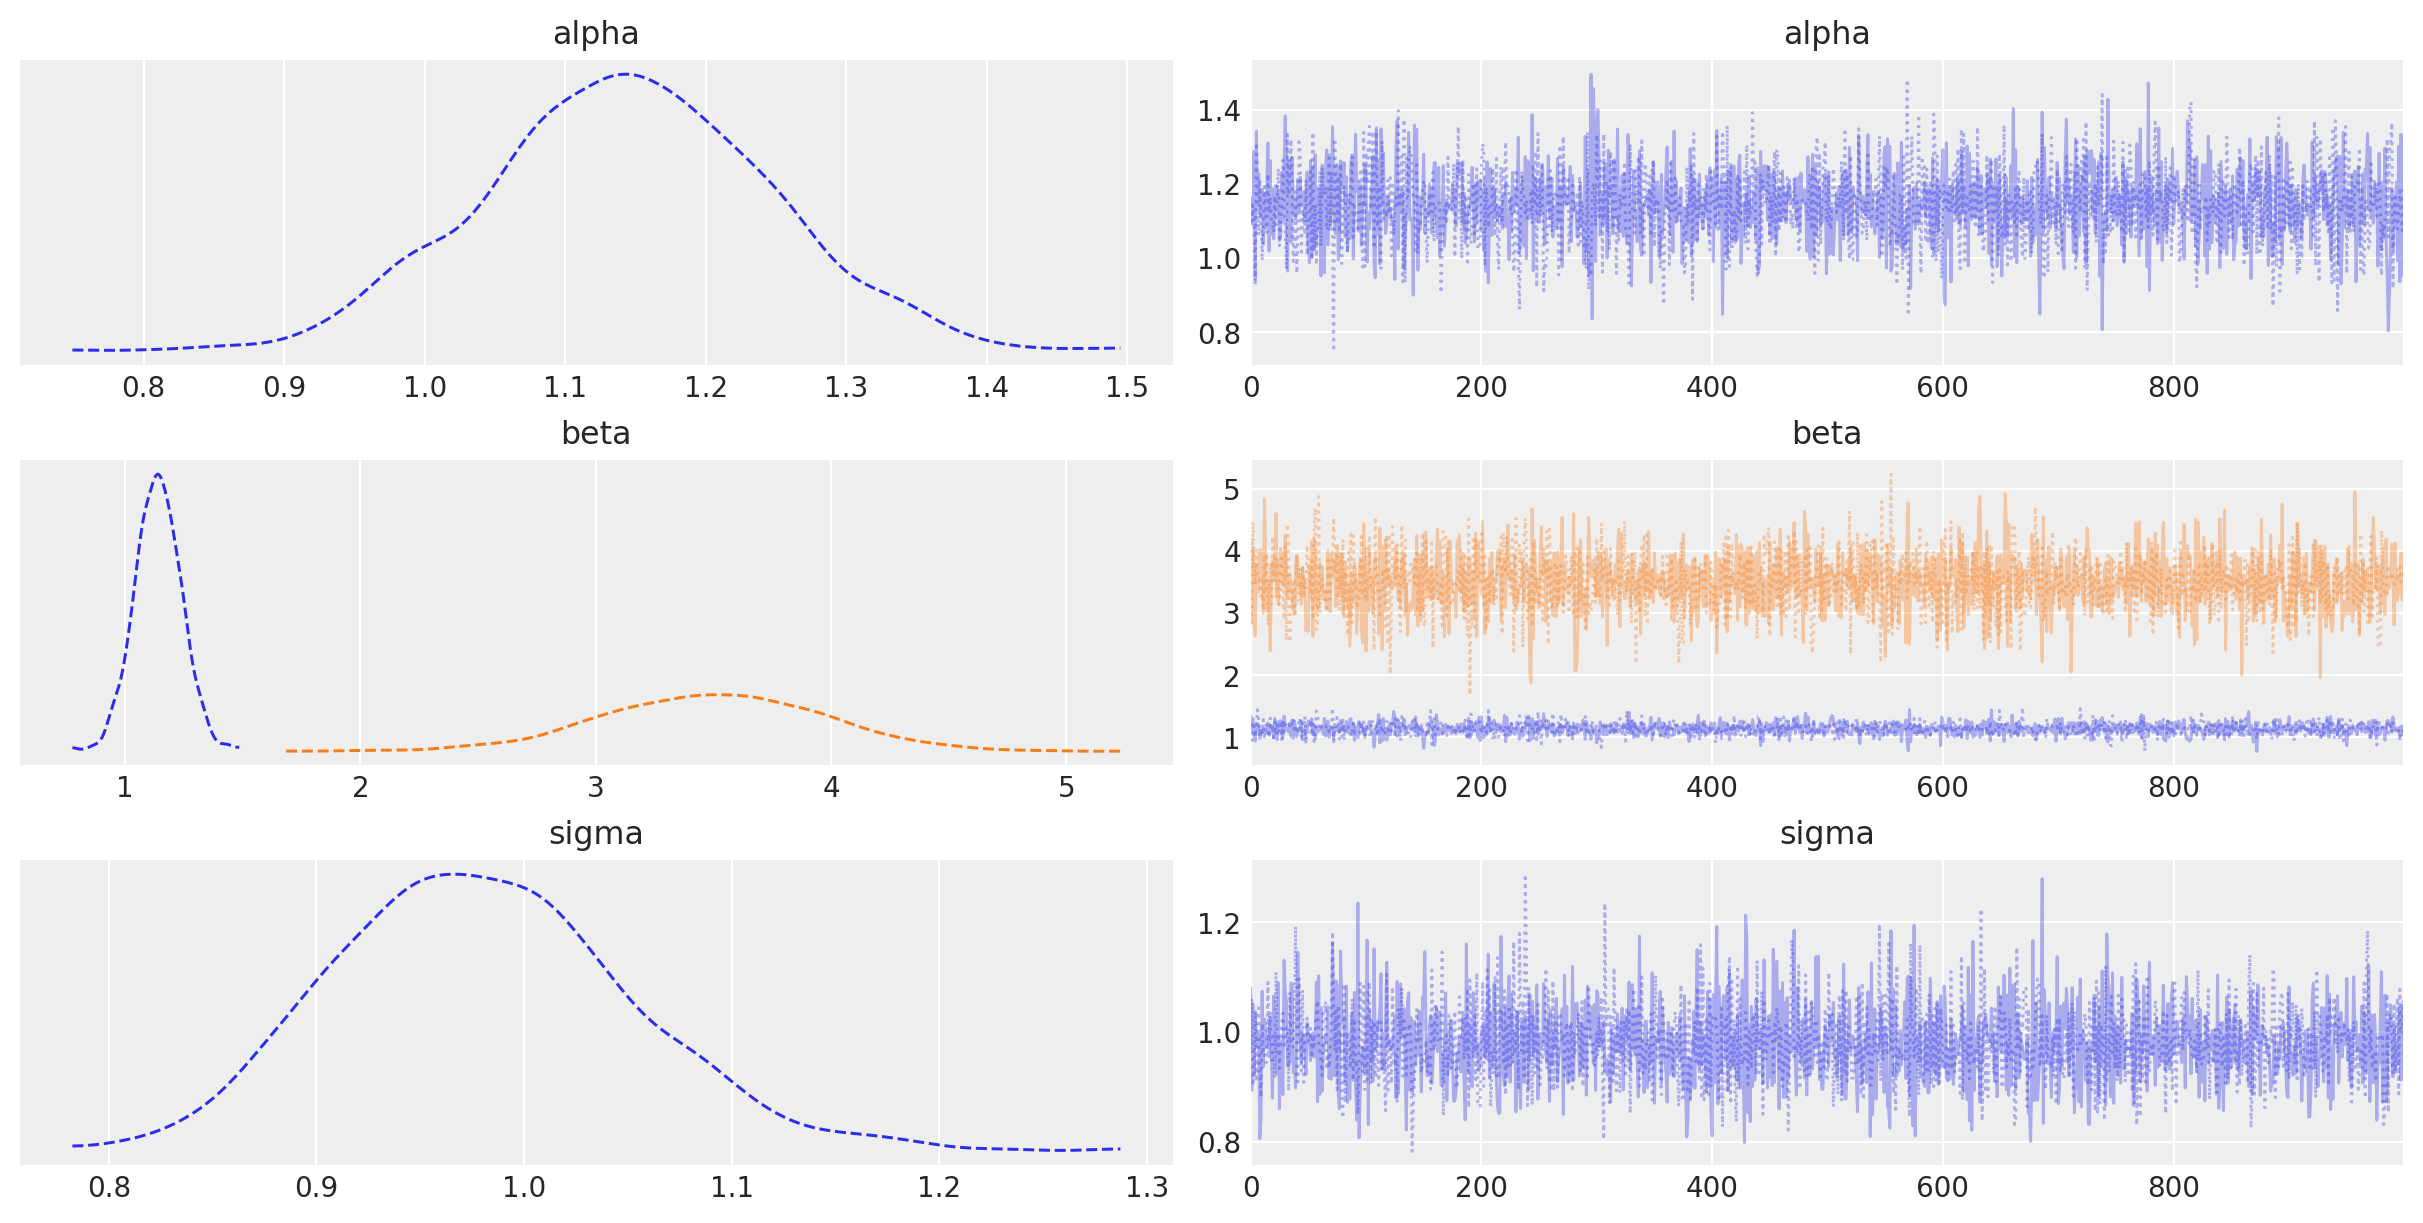

In [10]:
az.plot_trace(idata, combined=True)
# The left column consists of a smoothed histogram (using kernel density estimation) of the marginal posteriors of each stochastic
# random variable while the right column contains the samples of the Markov chain plotted in sequential order. The beta variable, 
# being vector-valued, produces two density plots and two trace plots, corresponding to both predictor coefficients.

az.summary(idata, round_to=2)

Occurrences of disasters in the time series is thought to follow a Poisson process with a large rate parameter in the early part of the time series, and from one with a smaller rate in the later part. We are interested in locating the change point in the series, which is perhaps related to changes in mining safety regulations.

In our model,
$𝐷_𝑡$∼Pois⁡($𝑟_𝑡$),
$$
r_t = 
\begin{cases}
e \quad \text{if} \quad t\le s \\
l \quad \text{if} \quad t\gt s
\end{cases}
$$

𝑠∼Unif⁡($t_𝑙$,$𝑡_ℎ$)

𝑒∼exp⁡(1)

𝑙∼exp⁡(1)

the parameters are defined as follows:

$𝐷_𝑡$: The number of disasters in year 𝑡.

$𝑟_𝑡$: The rate parameter of the Poisson distribution of disasters in year 𝑡.

𝑠: The year in which the rate parameter changes (the switchpoint).

𝑒: The rate parameter before the switchpoint 𝑠.

𝑙: The rate parameter after the switchpoint 𝑠.

$𝑡_𝑙$, $𝑡_ℎ$: The lower and upper boundaries of year 𝑡.

This model is built much like our previous models. The major differences are the introduction of discrete variables with the Poisson and discrete-uniform priors and the novel form of the deterministic random variable rate.

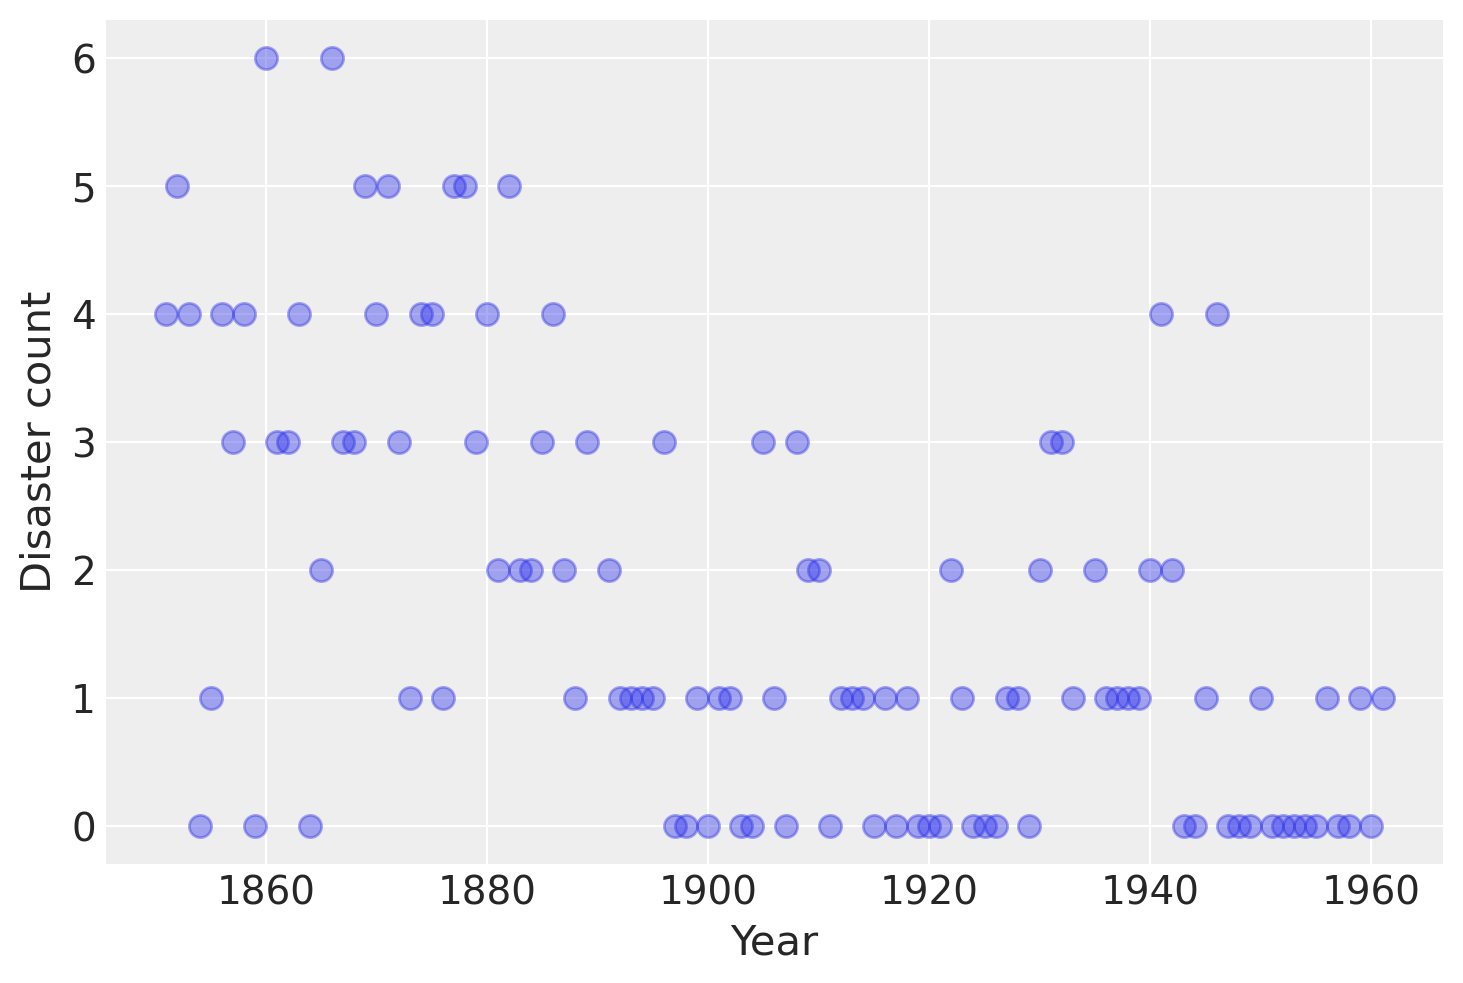

In [11]:
# fmt: off
disaster_data = pd.Series(
    [4, 5, 4, 0, 1, 4, 3, 4, 0, 6, 3, 3, 4, 0, 2, 6,
    3, 3, 5, 4, 5, 3, 1, 4, 4, 1, 5, 5, 3, 4, 2, 5,
    2, 2, 3, 4, 2, 1, 3, np.nan, 2, 1, 1, 1, 1, 3, 0, 0,
    1, 0, 1, 1, 0, 0, 3, 1, 0, 3, 2, 2, 0, 1, 1, 1,
    0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 2,
    3, 3, 1, np.nan, 2, 1, 1, 1, 1, 2, 4, 2, 0, 0, 1, 4,
    0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1]
)
# fmt: on
years = np.arange(1851, 1962)

plt.plot(years, disaster_data, "o", markersize=8, alpha=0.4)
plt.ylabel("Disaster count")
plt.xlabel("Year");

In [16]:
with pm.Model() as disaster_model:
    switchpoint = pm.DiscreteUniform("switchpoint", lower=years.min(), upper=years.max())

    # Priors for pre- and post-switch rates number of disasters
    early_rate = pm.Exponential("early_rate", 1.0)
    late_rate = pm.Exponential("late_rate", 1.0)

    # Allocate appropriate Poisson rates to years before and after current
    rate = pm.math.switch(switchpoint >= years, early_rate, late_rate)

    disasters = pm.Poisson("disasters", rate, observed=disaster_data)

with disaster_model:
    # https://www.pymc.io/projects/docs/en/stable/api/generated/pymc.sample.html
    idata = pm.sample(10000, chains=4, cores=4)

/home/mattia/anaconda3/envs/alice/lib/python3.13/site-packages/pymc/model/core.py:1302: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/home/mattia/anaconda3/envs/alice/lib/python3.13/site-packages/pymc/model/core.py:1316: ImputationWarning: Data in disasters contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CompoundStep
>>Metropolis: [switchpoint]
>>Metropolis: [disasters_unobserved]
>NUTS: [early_rate, late_rate]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 21 seconds.


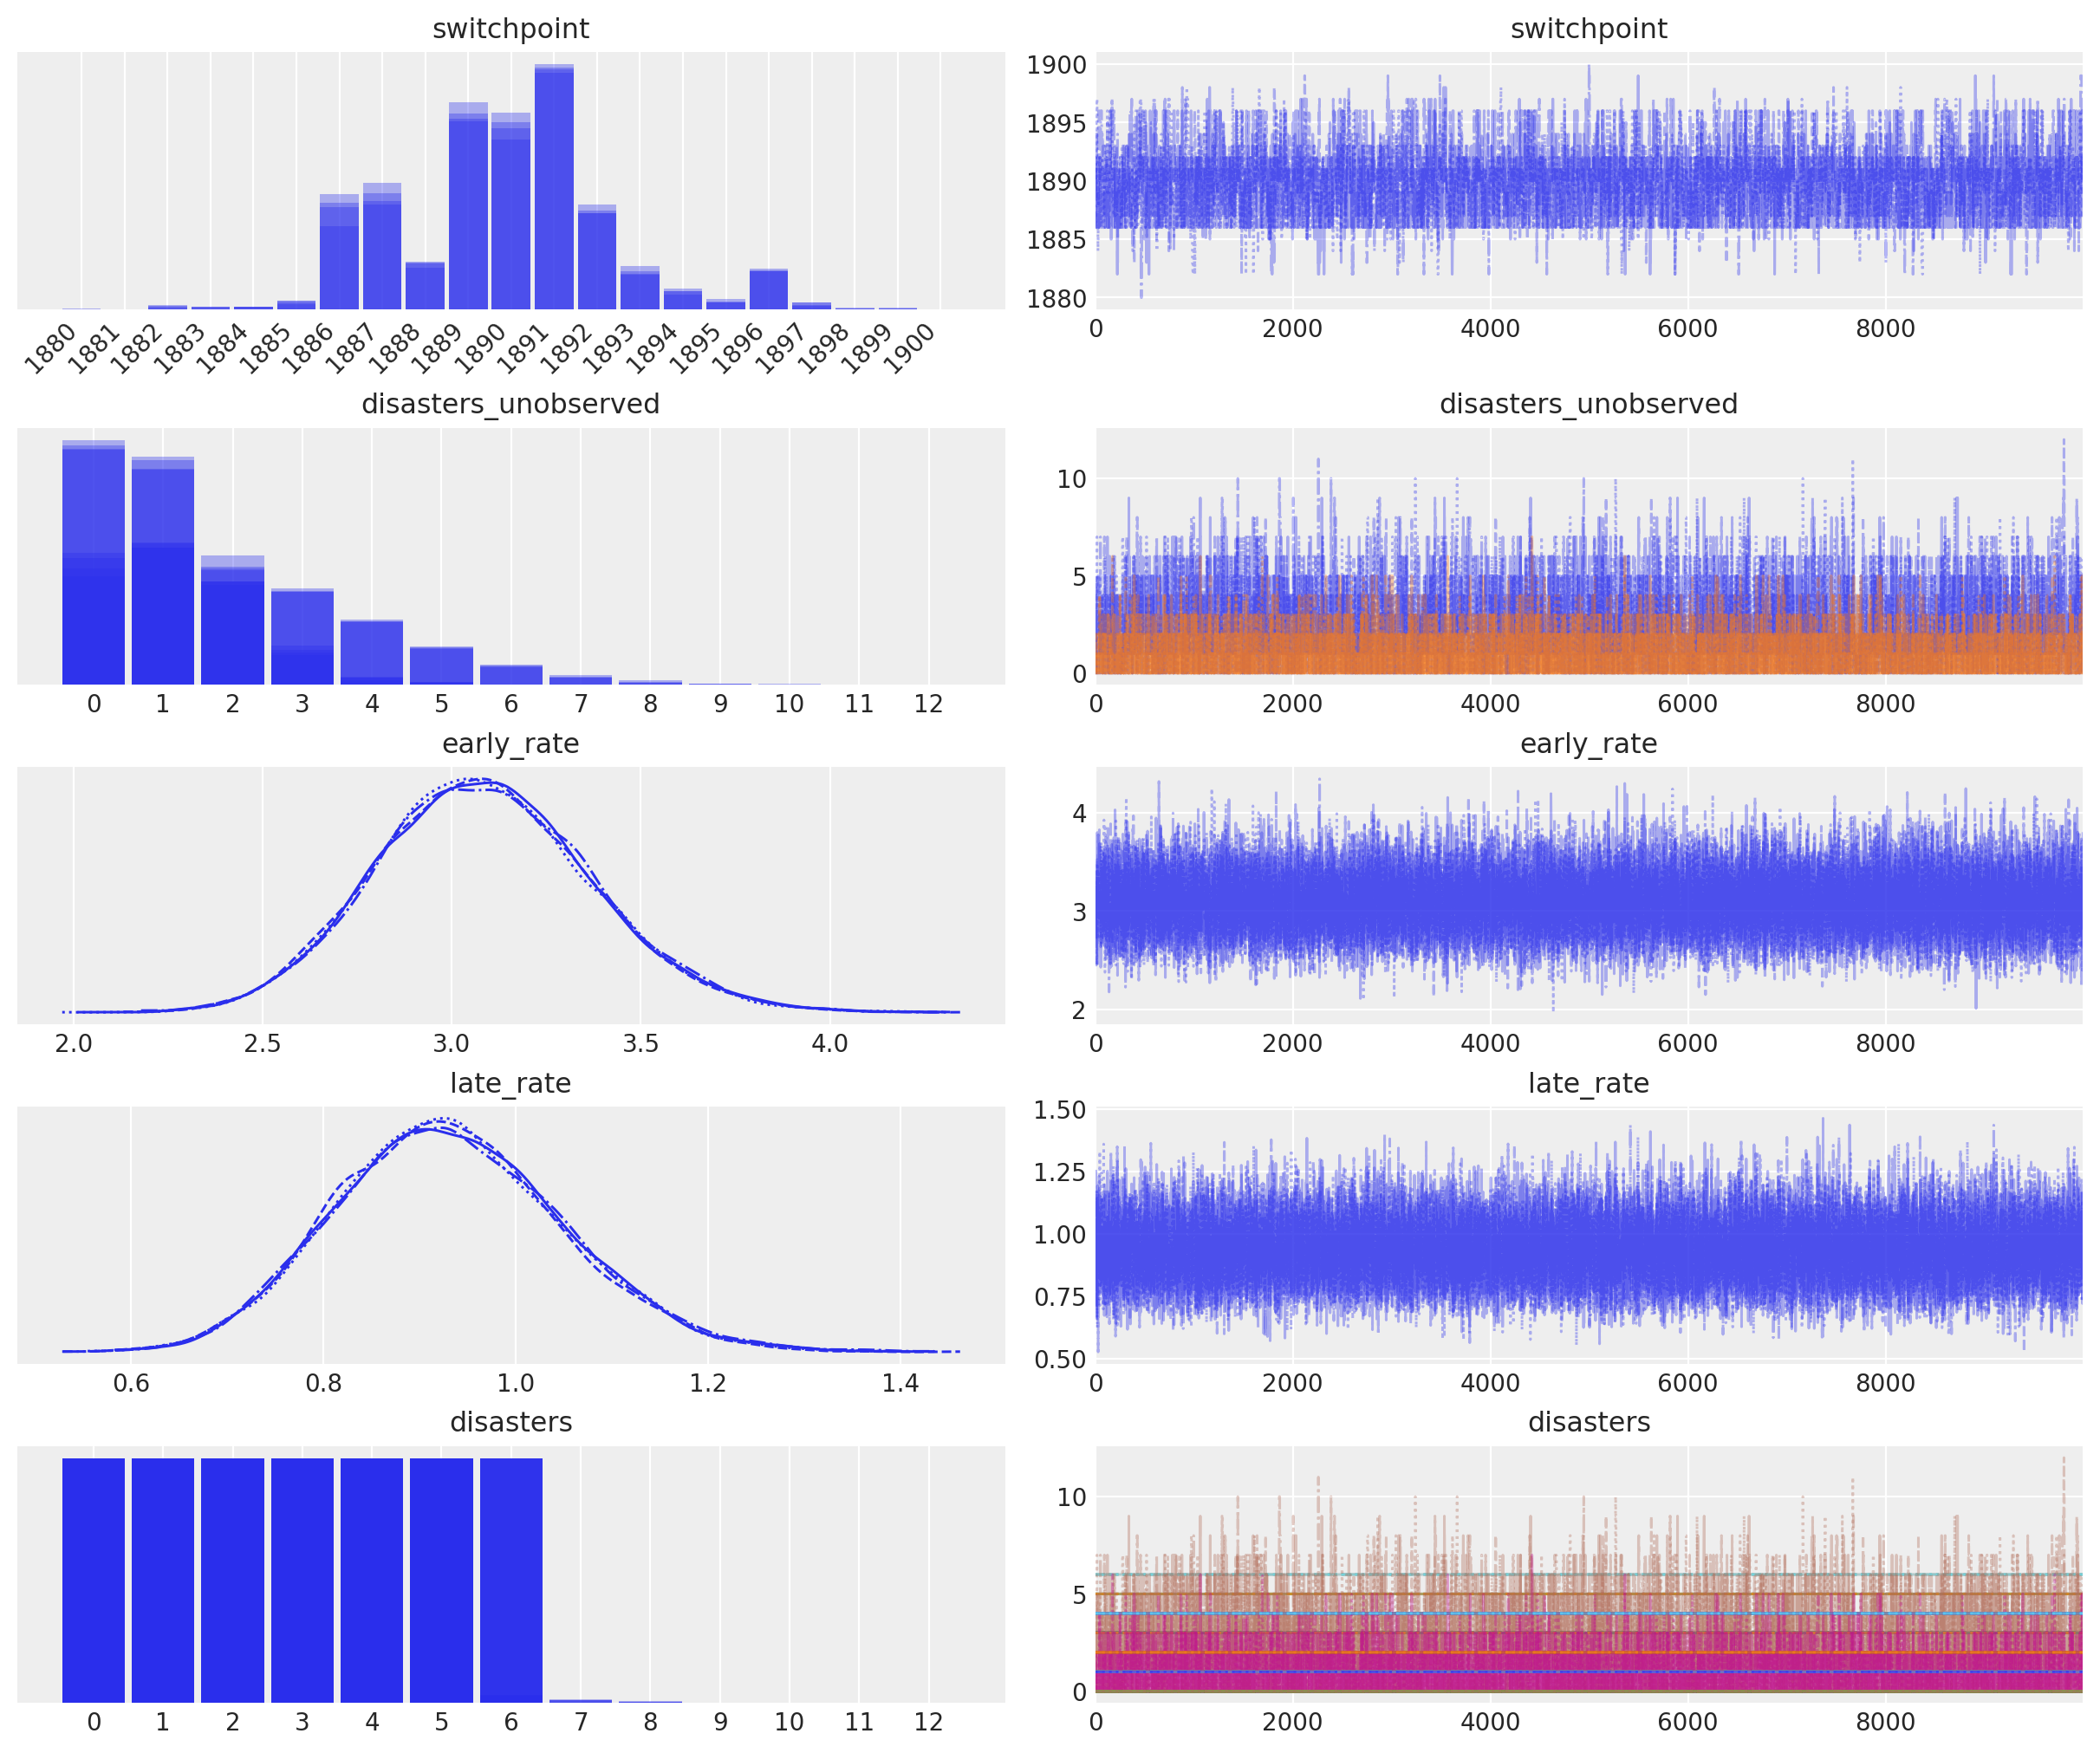

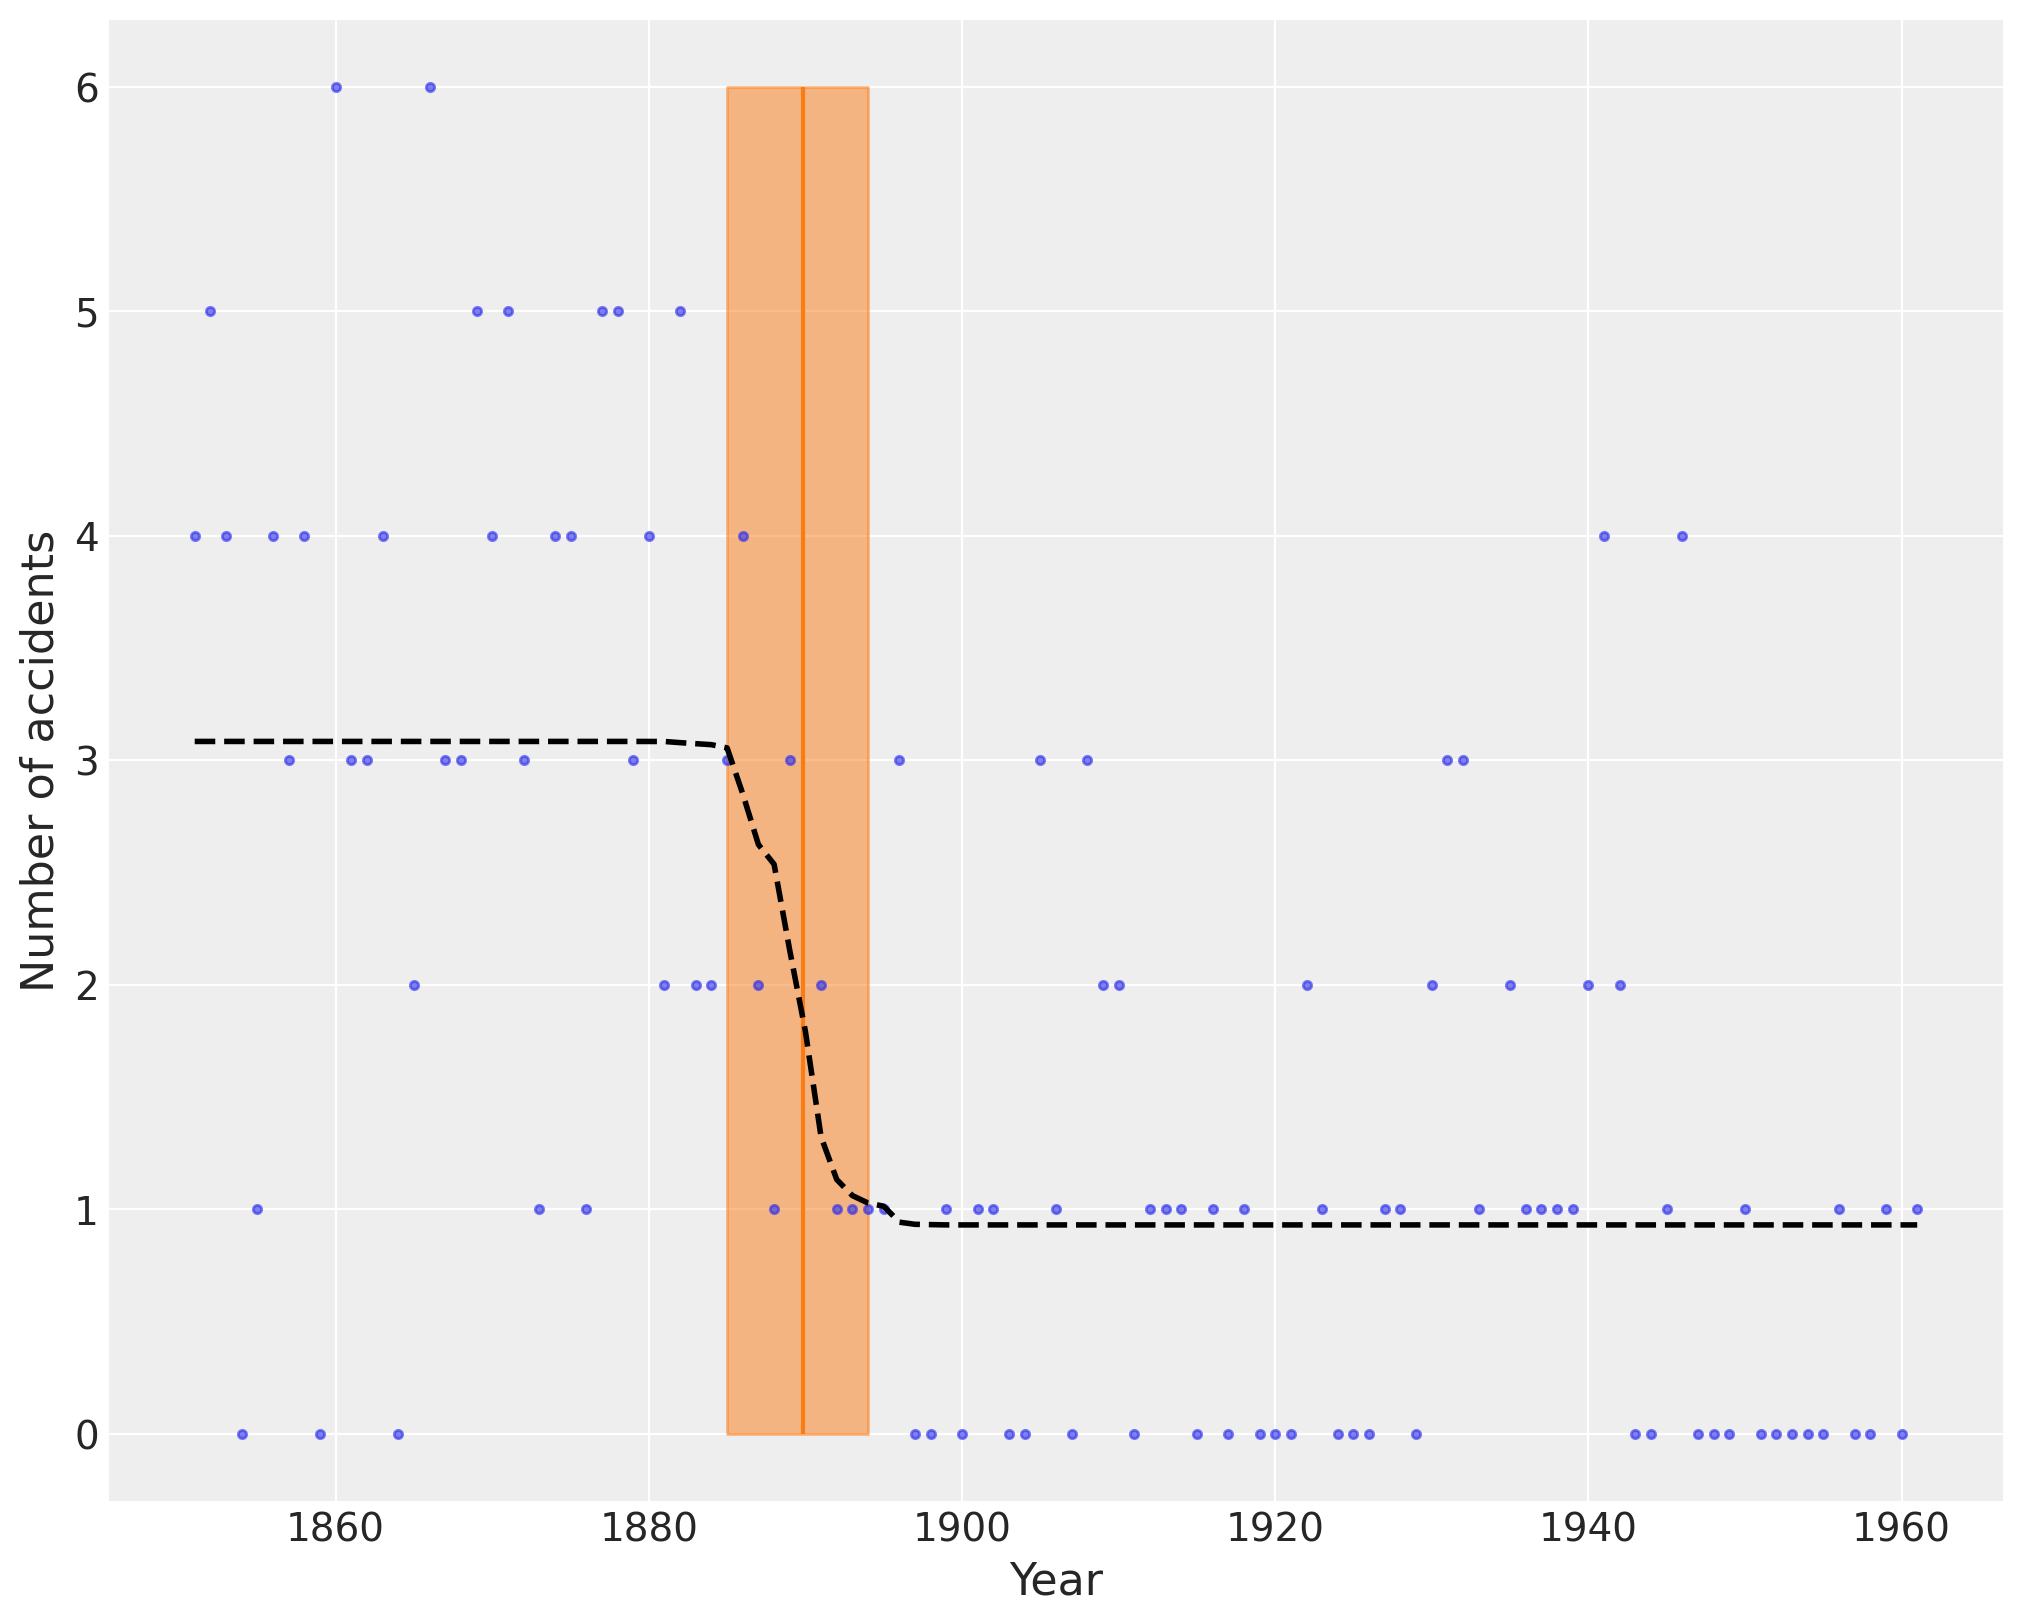

In [17]:
axes_arr = az.plot_trace(idata)
plt.draw()
for ax in axes_arr.flatten():
    if ax.get_title() == "switchpoint":
        labels = [label.get_text() for label in ax.get_xticklabels()]
        ax.set_xticklabels(labels, rotation=45, ha="right")
        break
plt.draw()

plt.figure(figsize=(10, 8))
plt.plot(years, disaster_data, ".", alpha=0.6)
plt.ylabel("Number of accidents", fontsize=16)
plt.xlabel("Year", fontsize=16)

trace = idata.posterior.stack(draws=("chain", "draw"))

plt.vlines(trace["switchpoint"].mean(), disaster_data.min(), disaster_data.max(), color="C1")
average_disasters = np.zeros_like(disaster_data, dtype="float")
for i, year in enumerate(years):
    idx = year < trace["switchpoint"]
    average_disasters[i] = np.mean(np.where(idx, trace["early_rate"], trace["late_rate"]))

sp_hpd = az.hdi(idata, var_names=["switchpoint"])["switchpoint"].values
plt.fill_betweenx(
    y=[disaster_data.min(), disaster_data.max()],
    x1=sp_hpd[0],
    x2=sp_hpd[1],
    alpha=0.5,
    color="C1",
)
plt.plot(years, average_disasters, "k--", lw=2)
plt.show()